In [1]:
# Import all the tools we need
import scanpy as sc        # Main scRNA-seq analysis library
import pandas as pd        # For working with tables
import numpy as np         # For math operations
import matplotlib.pyplot as plt  # For making plots
import seaborn as sns      # For nicer-looking plots
import scrublet as scr     # For detecting doublets (bad data)

# Scanpy display settings
sc.settings.verbosity = 3  # Show detailed progress messages
sc.settings.set_figure_params(dpi=100, facecolor='white')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the CellRanger count matrix
# Reads 3 files: matrix.mtx.gz, barcodes.tsv.gz, features.tsv.gz
adata = sc.read_10x_mtx(
    '/home/jupyter/data/pbmc_1k/filtered_feature_bc_matrix/',
    var_names='gene_symbols',  # Use gene names rather than Ensembl IDs
    cache=True                 # Cache so reloading is faster
)

# Make sure all gene names are unique
adata.var_names_make_unique()

# Print a summary
print(adata)

... writing an h5ad cache file to speedup reading next time
AnnData object with n_obs × n_vars = 1222 × 36601
    var: 'gene_ids', 'feature_types'


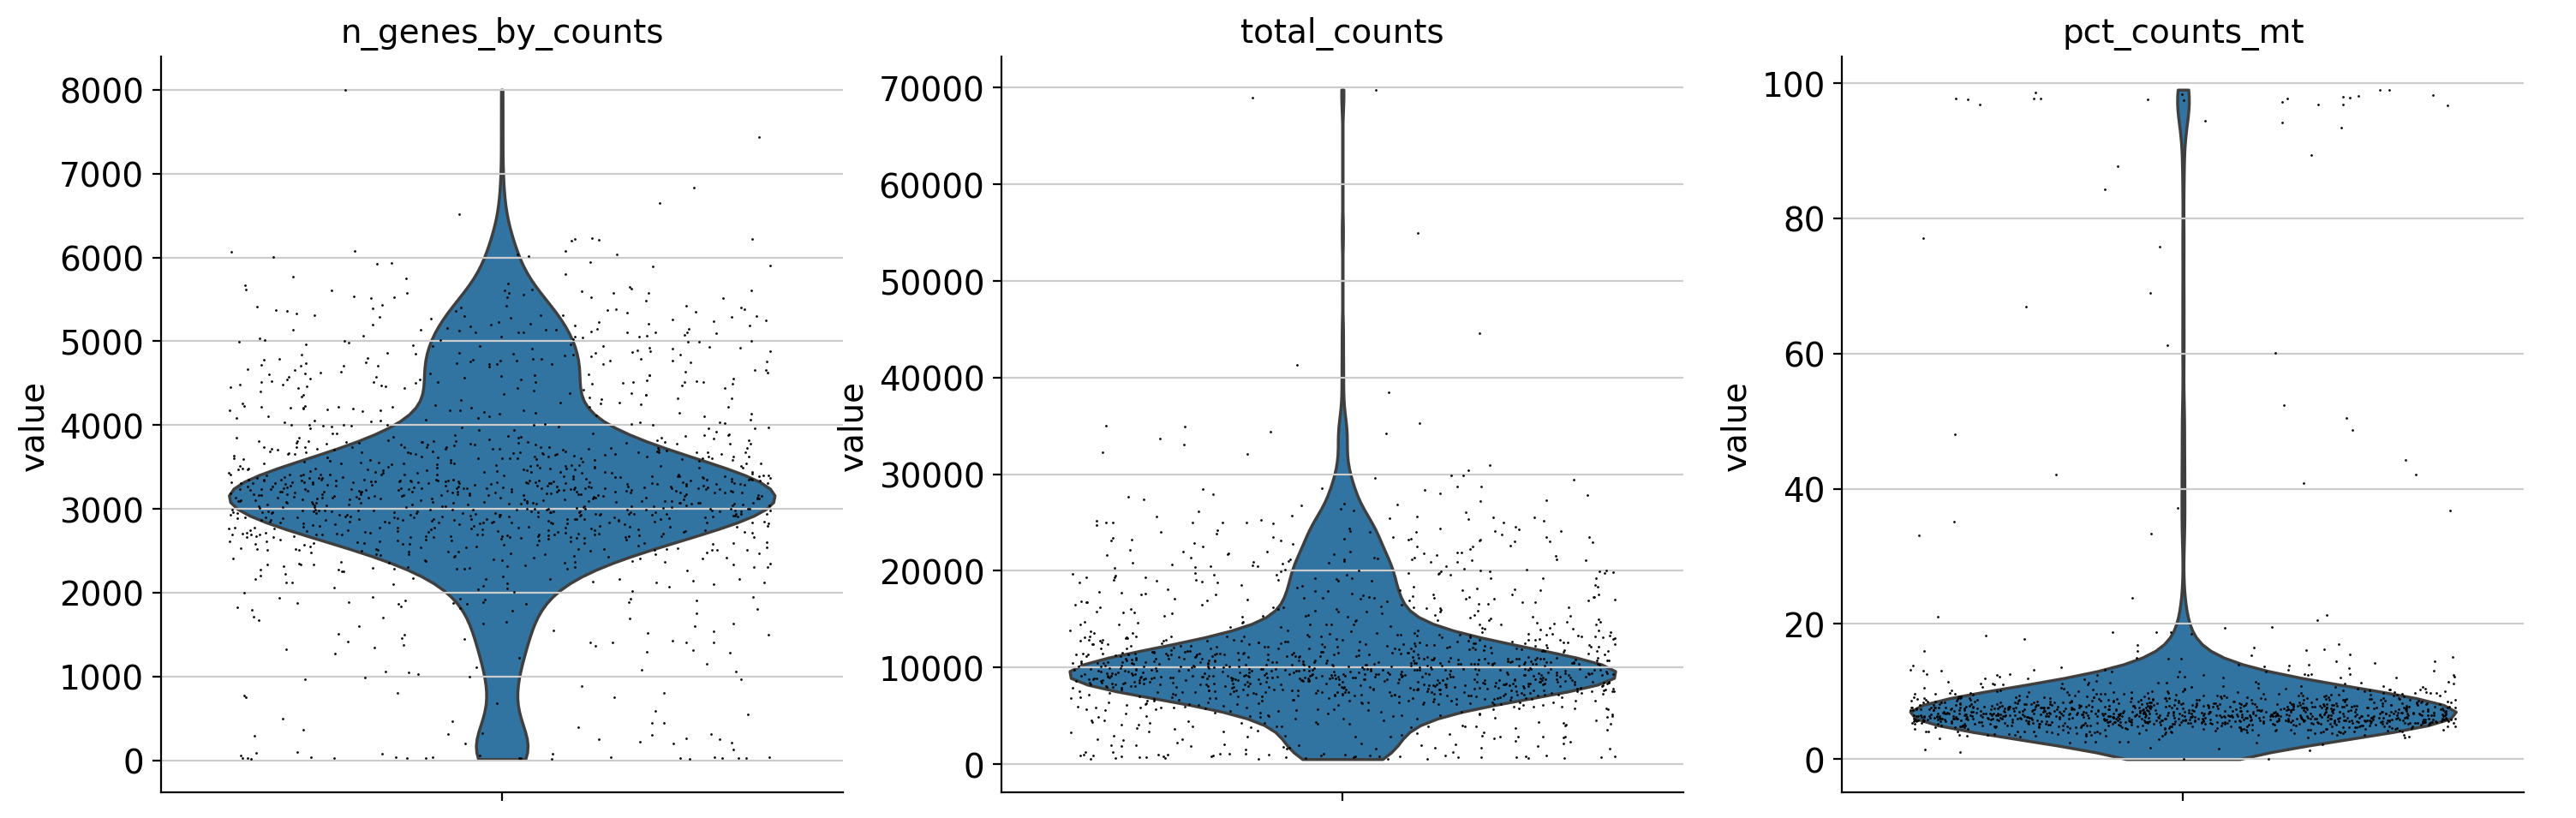

In [3]:
# Flag mitochondrial genes
# High mitochondrial gene % = dying or damaged cell
# Human mitochondrial genes all start with "MT-"
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Calculate QC metrics for every cell
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Plot the 3 key QC metrics as violin plots
# n_genes_by_counts = how many genes were detected in each cell
# total_counts      = total RNA molecules detected per cell
# pct_counts_mt     = % of RNA from mitochondrial genes
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

In [4]:
print(f"Before filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# Remove cells with too few genes (likely empty droplets)
adata = adata[adata.obs.n_genes_by_counts > 200, :]

# Remove cells with too many genes (likely two cells in one droplet)
adata = adata[adata.obs.n_genes_by_counts < 6000, :]

# Remove cells with high mitochondrial % (likely dying cells)
adata = adata[adata.obs.pct_counts_mt < 20, :]

# Remove genes detected in fewer than 3 cells (too rare to be useful)
sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering: {adata.n_obs} cells, {adata.n_vars} genes")

Before filtering: 1222 cells, 36601 genes
filtered out 16581 genes that are detected in less than 3 cells
After filtering: 1155 cells, 20020 genes


/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.41
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 52.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.5%
Elapsed time: 1.2 seconds


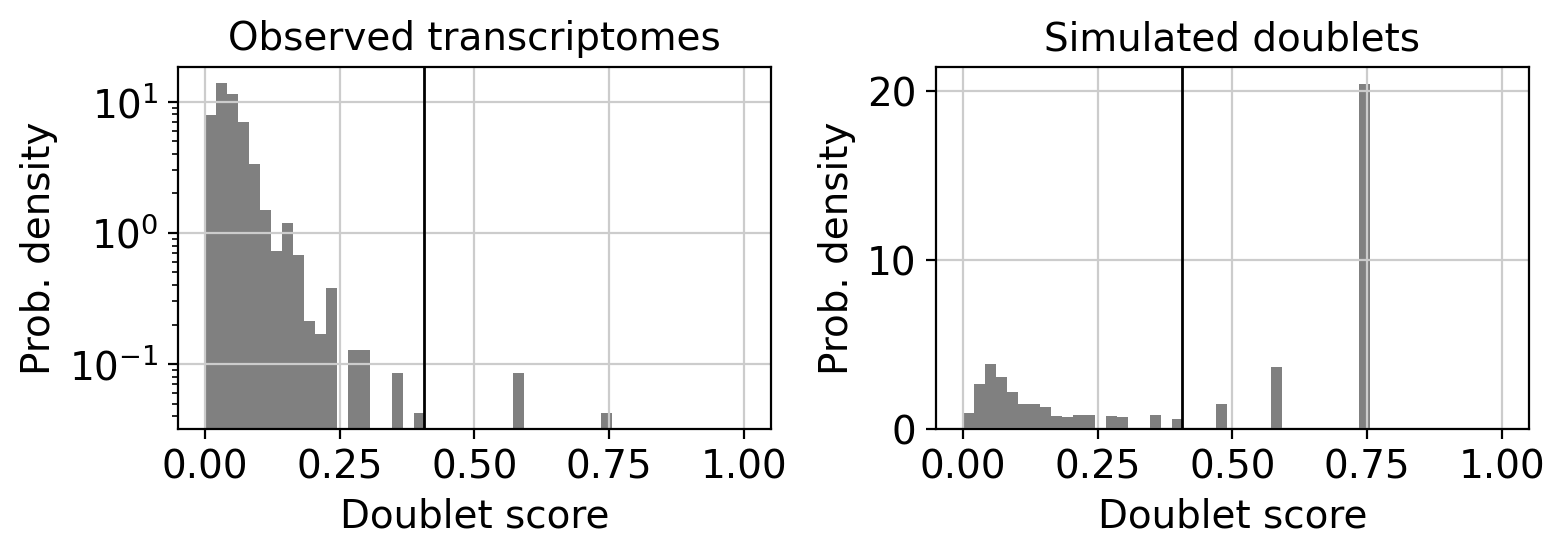

Cells after doublet removal: 1152


In [5]:
# Run Scrublet
scrub = scr.Scrublet(adata.X)
doublet_scores, predicted_doublets = scrub.scrub_doublets()

# Add results to our data object
adata.obs['doublet_score'] = doublet_scores
adata.obs['predicted_doublet'] = predicted_doublets

# Plot the score distribution — real cells and doublets should form 2 separate peaks
scrub.plot_histogram()
plt.show()

# Remove predicted doublets
adata = adata[~adata.obs['predicted_doublet'], :]
print(f"Cells after doublet removal: {adata.n_obs}")

In [6]:
# Save a copy of the raw counts — needed for differential expression later
adata.raw = adata

# Normalize: scale every cell to 10,000 total counts
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform: log(x+1) — reduces the effect of very highly expressed genes
sc.pp.log1p(adata)

print("Normalization complete!")

normalizing counts per cell
    finished (0:00:03)
Normalization complete!


extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


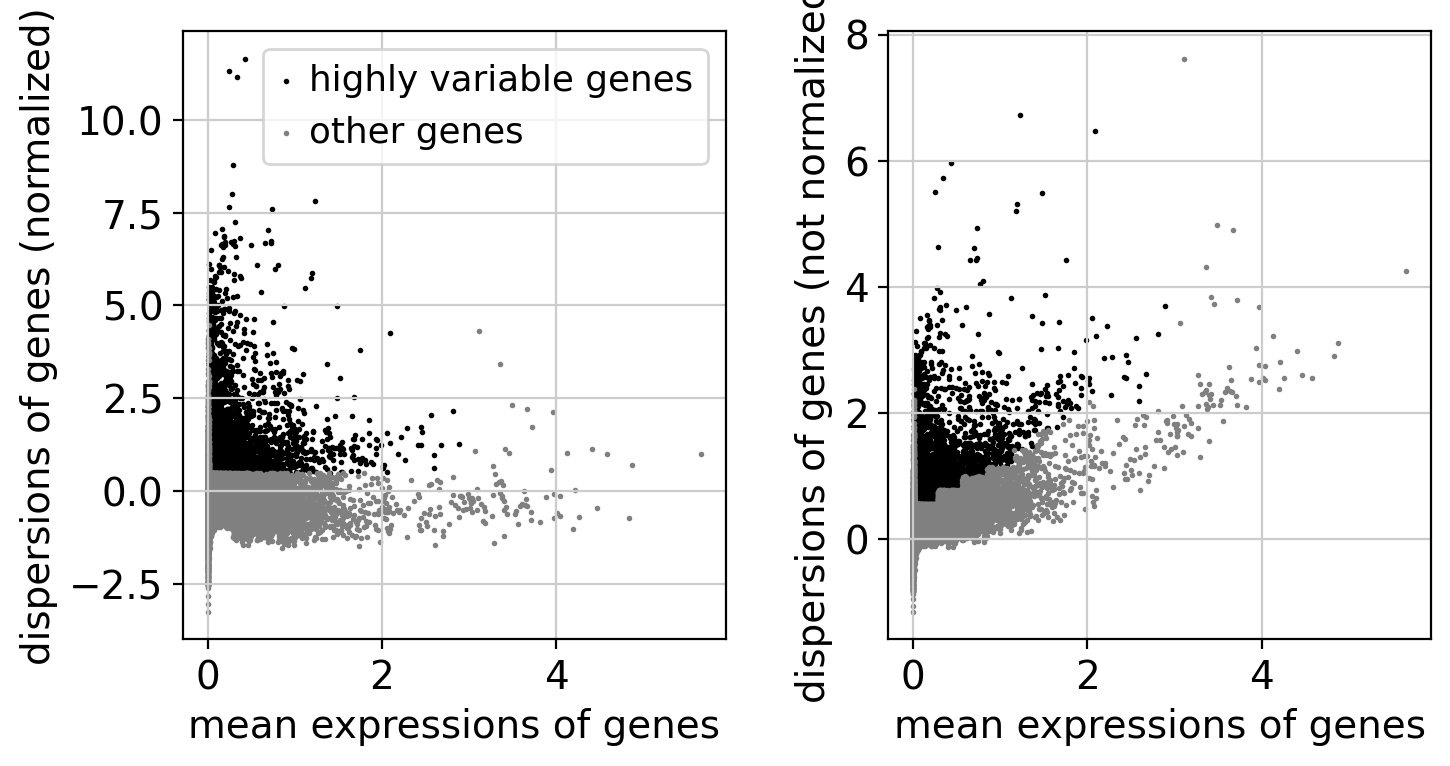

Highly variable genes selected: 3442


In [7]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

# Plot — highlighted dots are selected genes
sc.pl.highly_variable_genes(adata)

# Keep only the highly variable genes going forward
adata = adata[:, adata.var.highly_variable]
print(f"Highly variable genes selected: {adata.n_vars}")

In [8]:
# Remove technical effects of total counts and mitochondrial %
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale to unit variance, clip extreme outliers at 10
sc.pp.scale(adata, max_value=10)

print("Scaling complete!")

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/opt/conda/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:666: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


    finished (0:00:05)
Scaling complete!


computing PCA
    with n_comps=50
    finished (0:00:00)


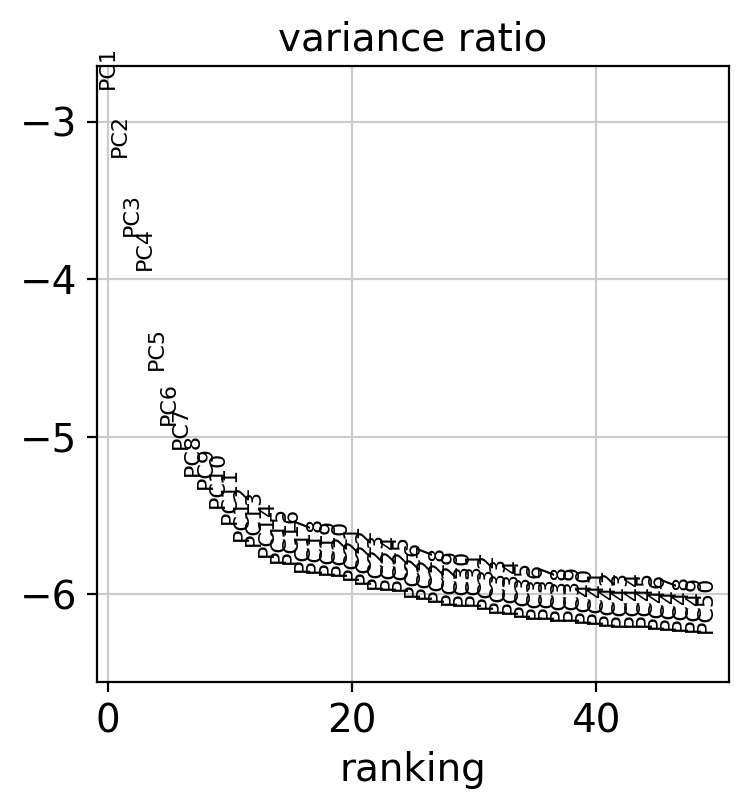

In [9]:
# Run PCA
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

# Elbow plot — look for where the curve flattens out ("the elbow")
# The elbow tells you how many PCs to use in the next step
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [10]:
# n_pcs=30: use the first 30 principal components
# Adjust based on your elbow plot from Step 16
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)

print("Neighborhood graph built!")

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:23)
Neighborhood graph built!


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


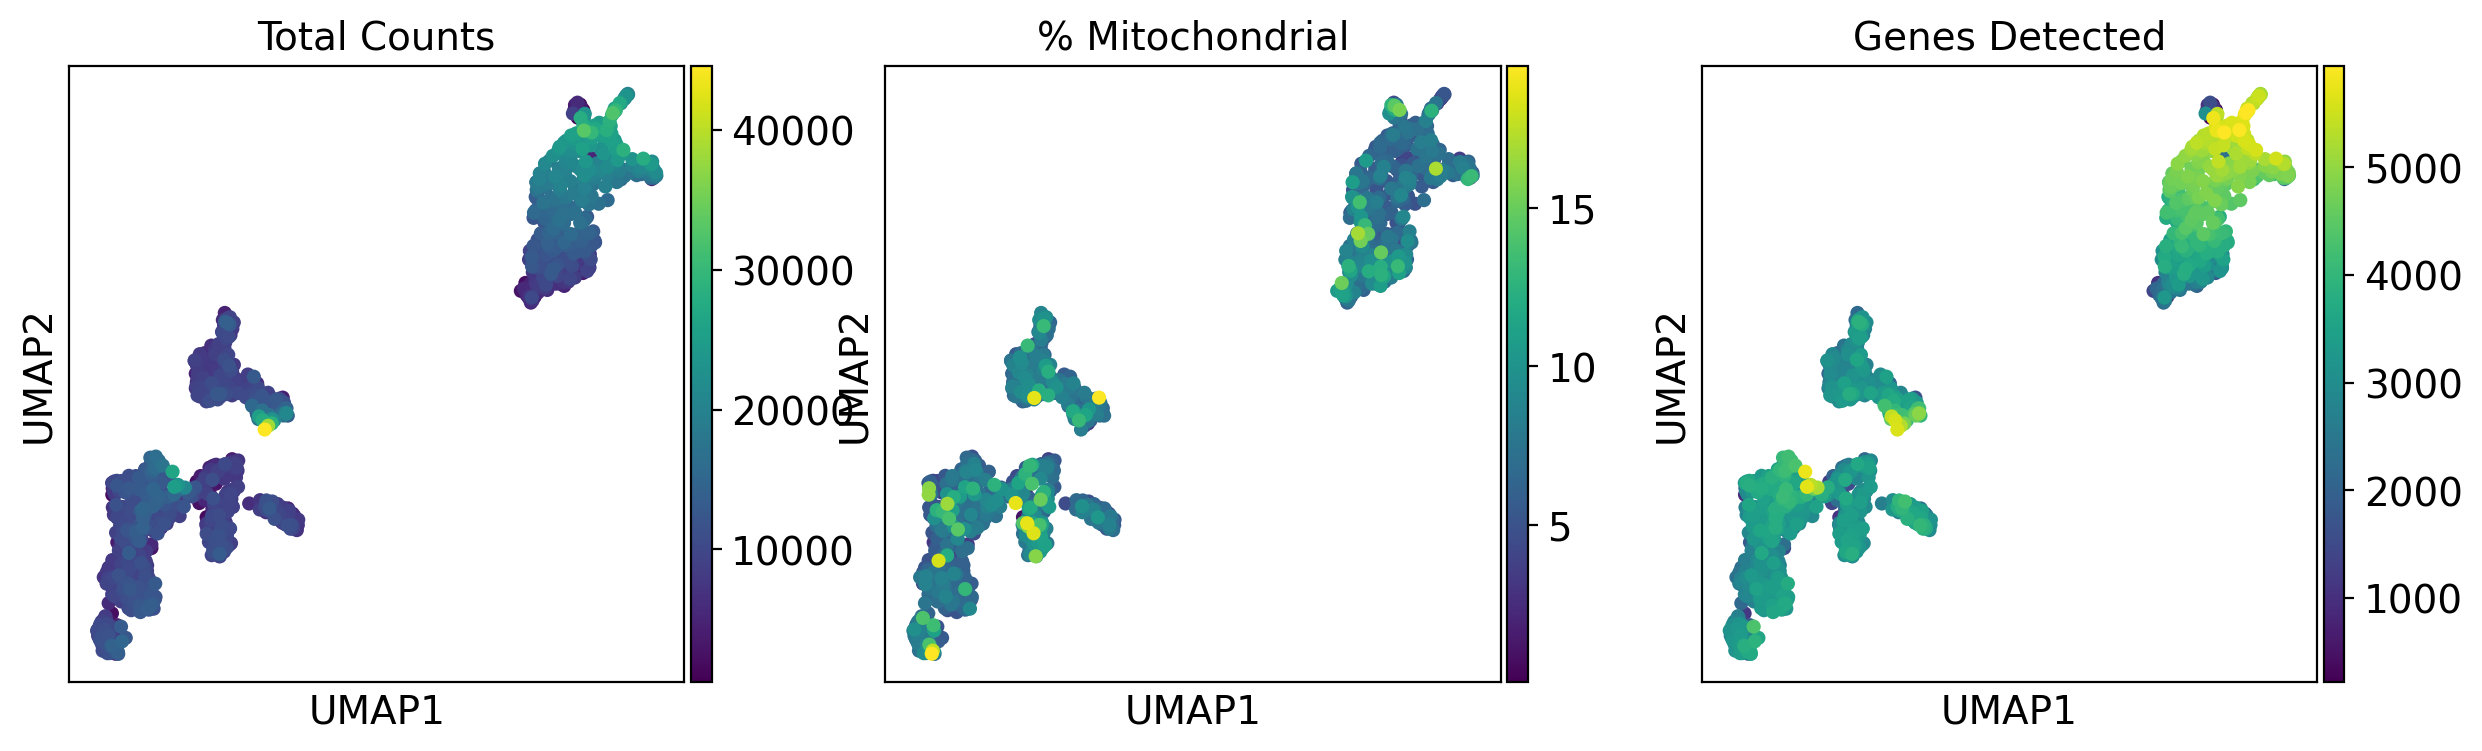

In [11]:
# Compute UMAP
sc.tl.umap(adata)

# Plot colored by QC metrics to make sure data looks clean
sc.pl.umap(
    adata,
    color=['total_counts', 'pct_counts_mt', 'n_genes_by_counts'],
    title=['Total Counts', '% Mitochondrial', 'Genes Detected']
)

running Leiden clustering


/var/tmp/ipykernel_11298/1032061084.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


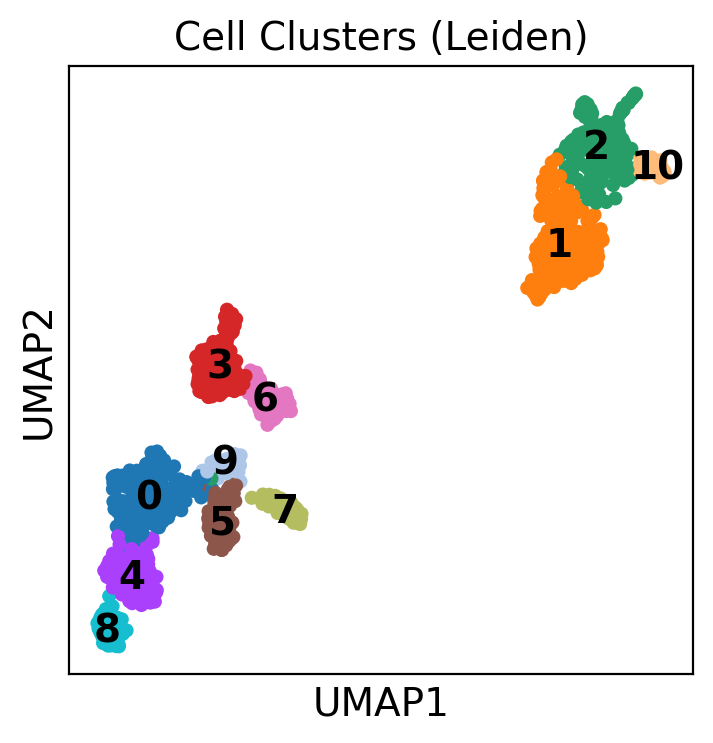

In [12]:
# Leiden clustering
# resolution controls number of clusters:
#   lower (0.3) = fewer bigger clusters
#   higher (1.0) = more smaller clusters
# Start with 0.5
sc.tl.leiden(adata, resolution=0.5)

# Plot clusters on UMAP
sc.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data',
    title='Cell Clusters (Leiden)'
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:09)


/opt/conda/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


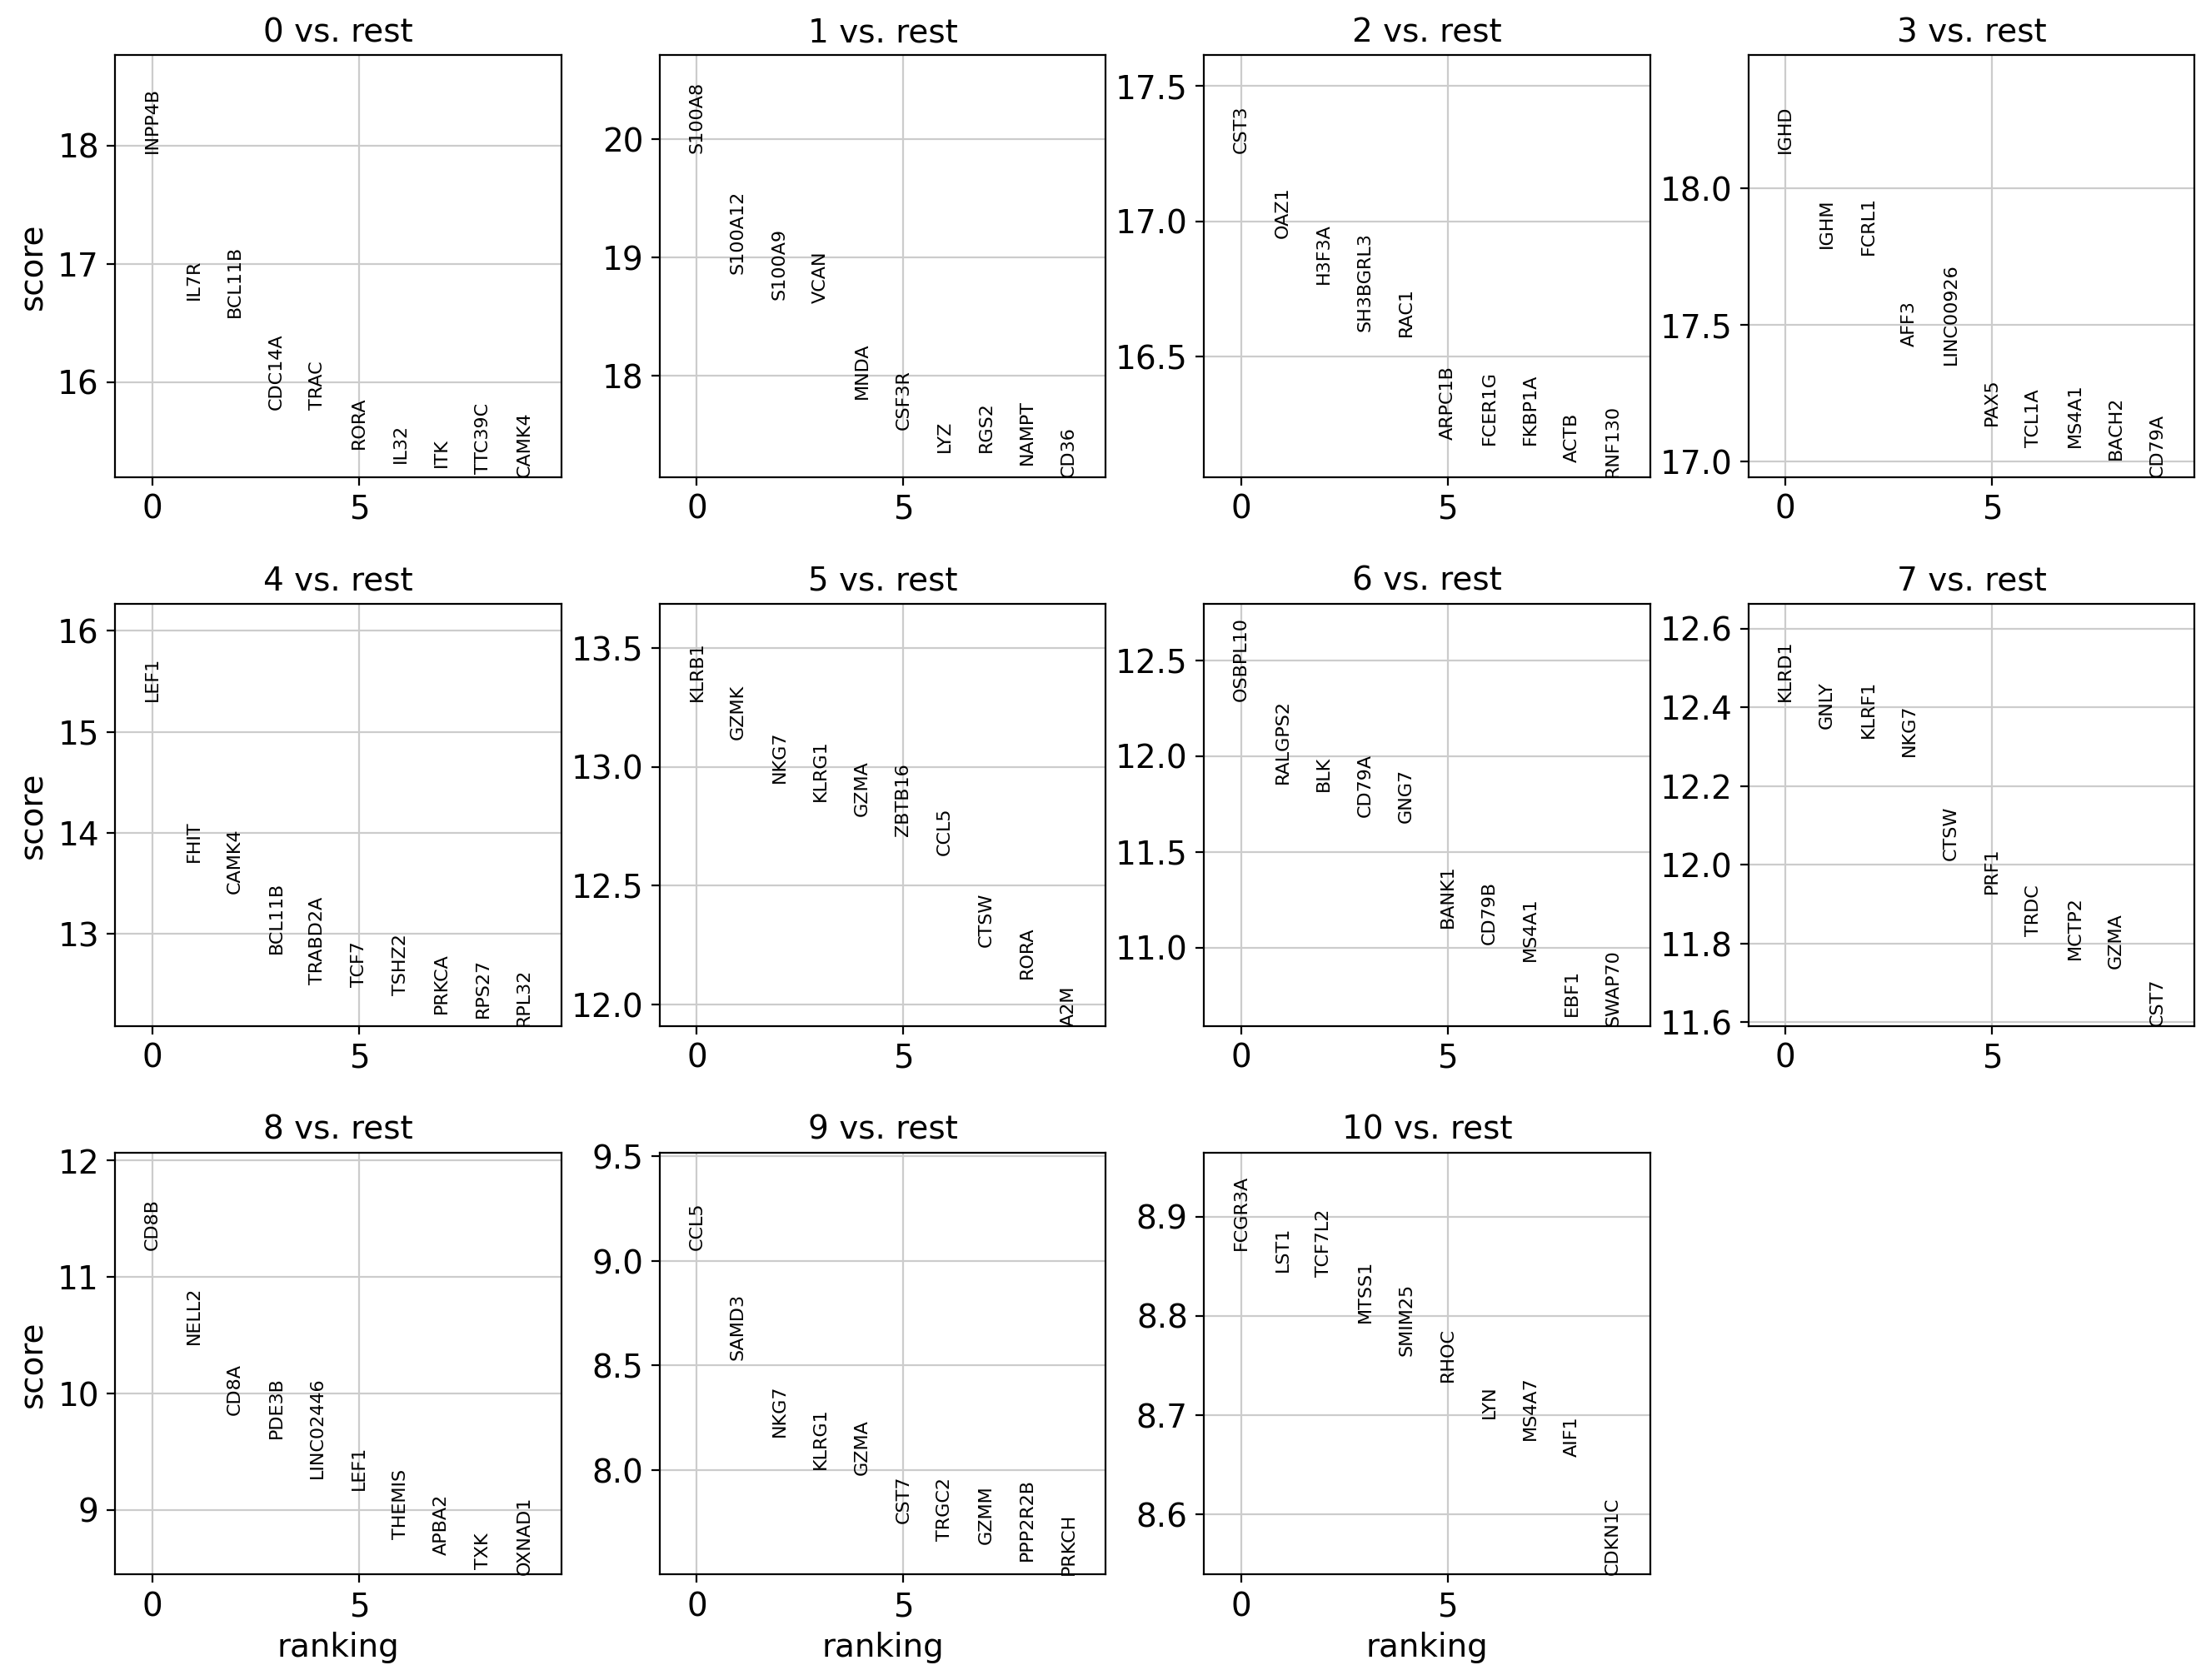

In [13]:
# Find marker genes using the Wilcoxon rank-sum test
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',
    method='wilcoxon',
    use_raw=True
)

# Plot top 10 marker genes per cluster
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [14]:
# Export to a table
import os
os.makedirs('/home/jupyter/results', exist_ok=True)

marker_df = sc.get.rank_genes_groups_df(adata, group=None)
print(marker_df.head(20))

# Save to CSV
marker_df.to_csv('/home/jupyter/results/marker_genes.csv', index=False)
print("Marker genes saved!")

   group     names     scores  logfoldchanges         pvals     pvals_adj
0      0    INPP4B  17.938063       12.973907  5.949385e-72  1.191067e-67
1      0      IL7R  16.693129       12.429416  1.470561e-62  1.472032e-58
2      0    BCL11B  16.548241       11.140808  1.648475e-61  1.100082e-57
3      0    CDC14A  15.767962        8.447951  5.169168e-56  2.162082e-52
4      0      TRAC  15.765203        6.958569  5.399805e-56  2.162082e-52
5      0      RORA  15.436132        8.001876  9.354419e-54  3.121258e-50
6      0      IL32  15.316867        9.860049  5.899336e-53  1.687210e-49
7      0       ITK  15.282052        4.464876  1.007179e-52  2.520466e-49
8      0    TTC39C  15.226441        6.005246  2.360977e-52  4.726676e-49
9      0     CAMK4  15.193465        6.857349  3.907078e-52  7.110882e-49
10     0  ARHGAP15  15.069374       21.215151  2.575414e-51  4.296650e-48
11     0   SERINC5  14.769028        7.633411  2.320366e-49  3.573364e-46
12     0       CD6  14.697330        4

... reading from cache file cache/home-jupyter-data-pbmc_1k-filtered_feature_bc_matrix-matrix.h5ad
normalizing counts per cell
    finished (0:00:00)


📂 Storing models in /home/jupyter/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 1152 cells and 36601 genes
🔗 Matching reference genes in the model
🧬 6147 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering


filtered out 18415 genes that are detected in less than 5 cells
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished: found 32 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


🗳️ Majority voting the predictions
✅ Majority voting done!


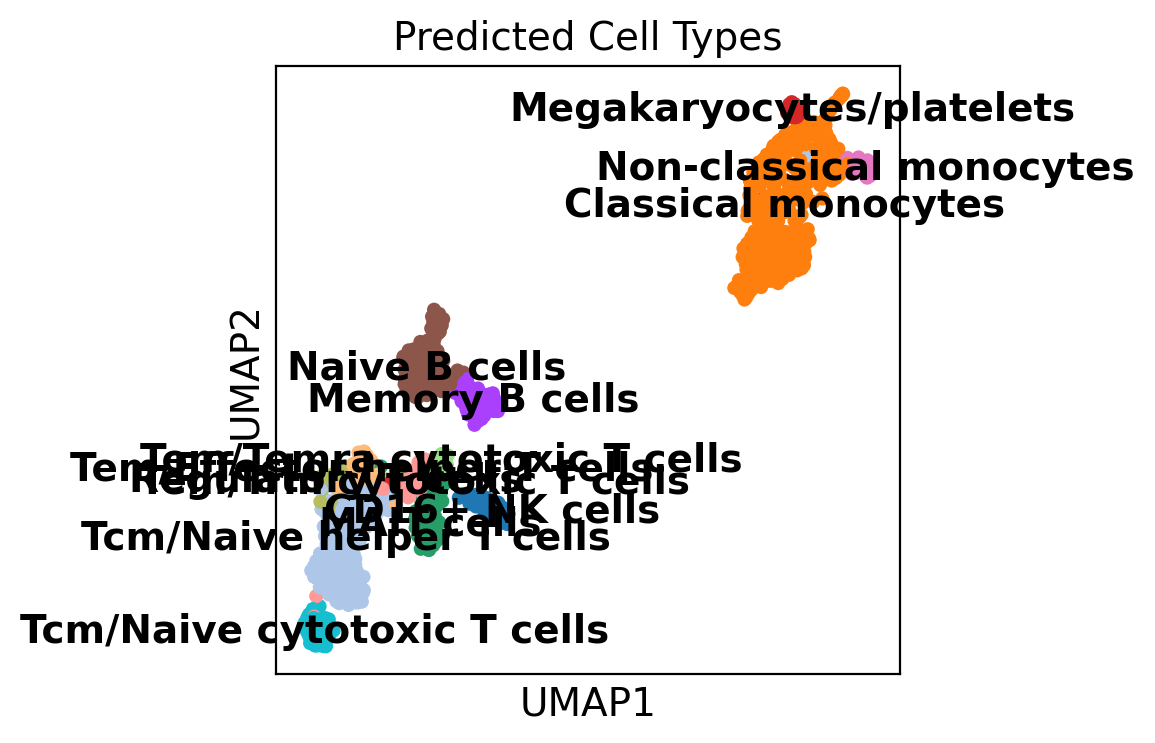

In [18]:
import celltypist
from celltypist import models

# Reload the original count matrix fresh
adata_celltypist = sc.read_10x_mtx(
    '/home/jupyter/data/pbmc_1k/filtered_feature_bc_matrix/',
    var_names='gene_symbols',
    cache=True
)
adata_celltypist.var_names_make_unique()

# Apply the same cell filtering we did earlier
adata_celltypist = adata_celltypist[adata.obs_names, :]

# Normalize exactly the way CellTypist expects
sc.pp.normalize_total(adata_celltypist, target_sum=1e4)
sc.pp.log1p(adata_celltypist)

# Download model (will skip if already downloaded)
models.download_models(model='Immune_All_Low.pkl')
model = models.Model.load(model='Immune_All_Low.pkl')

# Predict cell types
predictions = celltypist.annotate(adata_celltypist, model=model, majority_voting=True)

# Transfer predictions back to main adata
adata.obs['majority_voting'] = predictions.predicted_labels['majority_voting']

# Plot
sc.pl.umap(adata, color='majority_voting', legend_loc='on data', title='Predicted Cell Types')

In [ ]:
# Save the complete analysis object
adata.write('/home/jupyter/results/scrna_analyzed.h5ad')
print("Analysis object saved!")

# Save cell metadata (cluster IDs, cell types, QC metrics)
adata.obs.to_csv('/home/jupyter/results/cell_metadata.csv')

# Save UMAP coordinates
umap_df = pd.DataFrame(
    adata.obsm['X_umap'],
    columns=['UMAP1', 'UMAP2'],
    index=adata.obs_names
)
umap_df.to_csv('/home/jupyter/results/umap_coordinates.csv')

print("All files saved!")